# Градиентный спуск и линейные модели

[Линейные модели](https://ru.wikipedia.org/wiki/%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F) являются наиболее простыми моделями, используемыми в машинном обучении.

Традиционно этот класс моделей в большей степени используется для решения задач регрессии.

Детально описаны в библиотеке [scikit-learn.](https://scikit-learn.org/stable/modules/linear_model.html)

Линейные модели активно используются в [рекомендуемых методах scikit-learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) для регрессии.


In [1]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from scipy.optimize import fmin_tnc
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## Основы метода

В основе метода лежит гипотеза, что целевой признак $y$ линейно зависит от матрицы исходных признаков $X$ ($k$ - количество признаков): $y \sim X$.

Тогда значение целевого признака $y$ можно аппроксимировать с помощью линейной функции $f(x,b)$:

$$ y = f(x,b) + \epsilon$$
$$ \hat{y} = f(x,b) $$
$$ y = \hat{y} + \epsilon$$
где:
- $y$ - истинное значение целевого признака
- $\hat{y}$ - предсказанное значение целевого признака
- $\epsilon$ - ошибка модели


Ошибка всегда присутствует, ведь на практике нет никакой гарантии, что зависимость между исходными признаками и целевым признаком действительно линейная.

В модели линейной регресии $\hat{y} = f(x,b)$ можно представить как скалярное произведение вектора признаков (регрессоров или факторов) $x_i$ на вектор коэффициентов модели $b_i$:

$$ \hat{y} = f(x,b) = b_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n $$

Коэффициент $b_0$ (константу) можно рассматривать как коэффициент при нулевом признаке, который всегда равен 1 ($x_0=1$). Тогда:

$$ \hat{y} = f(x,b) = b_0 \cdot x_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n = \sum\limits_{j=0}^N b_j \cdot x_j = x^T b $$

Построение модели линейной регресии означает нахождение всех коэффициентов $b_i$ на основании известных значений матрицы исходных признаков $X$ и вектора целевого признака $y$ из обучающей выборки.

Фактически, нужно найти такие значения $b_i$, которые минимизируют ошибку $\epsilon$.

Значение коэффициентов $b_i$ может быть найдено:
1. аналитически
1. с использованием численных методов (что используется на практике наиболее часто)




Для удобства демонстрации метода рассмотрим частный случай с единственным регрессором: 
$$ y = \hat{y} + \epsilon$$
$$ \hat{y} = b_0 + b_1 \cdot x_1 $$

### Подготовка данных

В качестве набора данных будем использовать Housing dataset.

In [2]:
Housing = pd.read_csv('data/housing_train.csv', sep=",")

target датасета будет median_house_value - именно его будем предсказывать по остальным признакам.

<Axes: >

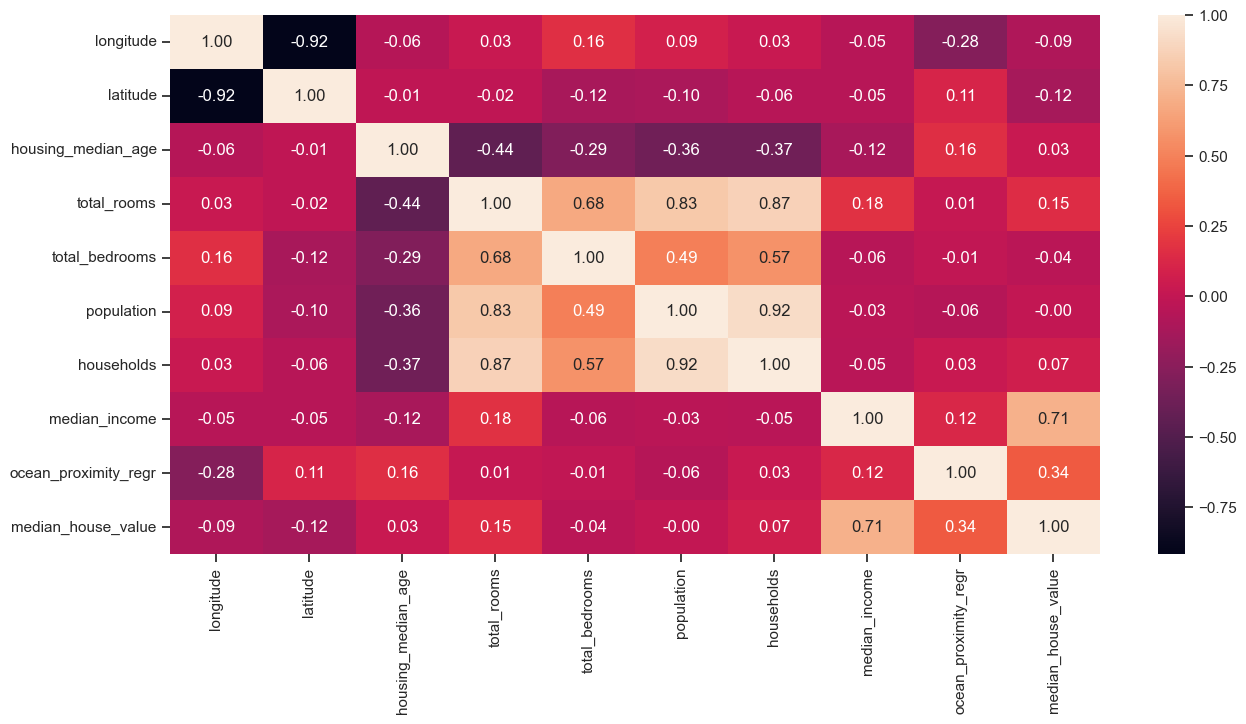

In [3]:
#Построим корреляционную матрицу
fig, ax = plt.subplots(figsize=(15,7))
Housing_regr = Housing.drop(columns='ocean_proximity')
sns.heatmap(Housing_regr.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')

<Axes: xlabel='median_income', ylabel='median_house_value'>

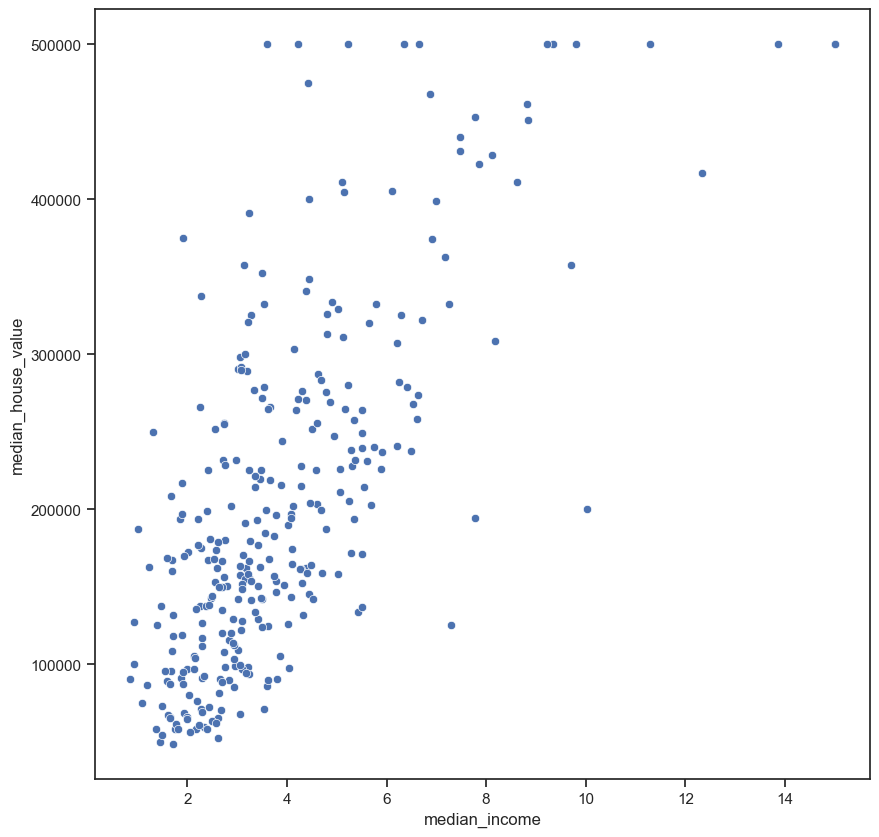

In [4]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='median_income', y='median_house_value', data=Housing_regr)

Между признаком "median_income" и целевым признаком "median_house_value" существует зависимость, подобная линейной в малых значениях , коэффициент корреляции = 0,71

Попробуем восстановить данную линейную зависимость.

## Аналитическое восстановление зависимости

Для аналитического восстановления зависимости можно использовать следующие формулы (которые выводятся на основе рассматриваемого далее метода наименьших квадратов).

Пусть $\overline{x}$ - среднее значение для x, а $\overline{y}$ - среднее значение для y.

Тогда для средних значений рассматриваемой выборки:

$$ \overline{y} = b_0 + b_1 \overline{x} $$

Примем без вывода что:

$$ b_1 = \frac{\frac{1}{k} \cdot \sum\limits_{i=1}^k (x_i - \overline{x}) \cdot (y_i - \overline{y})}{\frac{1}{k} \cdot \sum\limits_{i=1}^k (x_i - \overline{x})^2} = \frac{Cov(x,y)}{Var(x)} $$

где:
- Cov(x,y) - [ковариация](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D0%B2%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D1%8F) между величинами x,y.
- Var(x) - [дисперсия](https://ru.wikipedia.org/wiki/%D0%94%D0%B8%D1%81%D0%BF%D0%B5%D1%80%D1%81%D0%B8%D1%8F_%D1%81%D0%BB%D1%83%D1%87%D0%B0%D0%B9%D0%BD%D0%BE%D0%B9_%D0%B2%D0%B5%D0%BB%D0%B8%D1%87%D0%B8%D0%BD%D1%8B) x.

Тогда:

$$ b_0 = \overline{y} - b_1 \overline{x} $$

Вывод приведен [здесь.](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BD%D0%B0%D0%B8%D0%BC%D0%B5%D0%BD%D1%8C%D1%88%D0%B8%D1%85_%D0%BA%D0%B2%D0%B0%D0%B4%D1%80%D0%B0%D1%82%D0%BE%D0%B2#%D0%9C%D0%9D%D0%9A_%D0%B2_%D1%81%D0%BB%D1%83%D1%87%D0%B0%D0%B5_%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%BE%D0%B9_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8)

In [5]:
# Аналитическое вычисление коэффициентов регрессии
def analytic_regr_coef(x_array : np.ndarray, 
                       y_array : np.ndarray) -> Tuple[float, float]:
    x_mean = np.mean(x_array)
    y_mean = np.mean(y_array)
    var1 = np.sum([(x-x_mean)**2 for x in x_array])
    cov1 = np.sum([(x-x_mean)*(y-y_mean) for x, y in zip(x_array, y_array)])
    b1 = cov1 / var1
    b0 = y_mean - b1*x_mean
    return b0, b1

In [6]:
x_array = Housing_regr['median_income'].values
y_array = Housing_regr['median_house_value'].values

In [7]:
b0, b1 = analytic_regr_coef(x_array, y_array)
b0, b1

(np.float64(59283.88316602097), np.float64(37006.97234283177))

**Аналитически вычисленные коэффициенты b0, b1 будут использоваться в дальнейшем для сравнения с другими моделями.**

In [8]:
# Вычисление значений y на основе x для регрессии
def y_regr(x_array : np.ndarray, b0: float, b1: float) -> np.ndarray:
    res = [b1*x+b0 for x in x_array]
    return res

In [9]:
y_array_regr = y_regr(x_array, b0, b1)

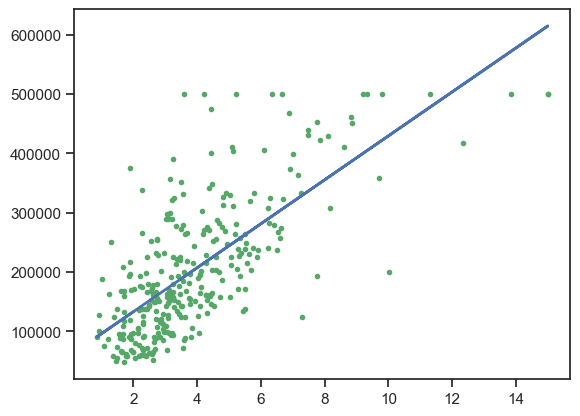

In [10]:
plt.plot(x_array, y_array, 'g.')
plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
plt.show()

## Восстановление зависимости с использованием численных методов

Смысл использования всех численных методов сводится к тому, чтобы в выражении $y = \hat{y} + \epsilon$ минимизировать ошибку $\epsilon \rightarrow min$ (или какой-либо функцию от ошибки, называемую функцией потерь - $L$), то есть насколько это возможно приблизить предсказанные значения $\hat{y}$ к действительным значениям $y$.

Одним из наиболее часто используемых методов является метод наименьших квадратов.

### [Метод наименьших квадратов](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BD%D0%B0%D0%B8%D0%BC%D0%B5%D0%BD%D1%8C%D1%88%D0%B8%D1%85_%D0%BA%D0%B2%D0%B0%D0%B4%D1%80%D0%B0%D1%82%D0%BE%D0%B2)

В методе наименьших квадратов в качестве функции потерь используется квадрат ошибки $\epsilon^2$.

Решается задача оптимизации:

$$ L = \epsilon^2 \rightarrow min = \sum\limits_{i=1}^k \epsilon_i^2 \rightarrow min = \sum\limits_{i=1}^k (y_i - \hat{y}_i)^2 \rightarrow min $$

Проиллюстрируем метод наименьших квадратов. Для первых K=10 точек покажем ошибки между истинными и предсказанными значениями:

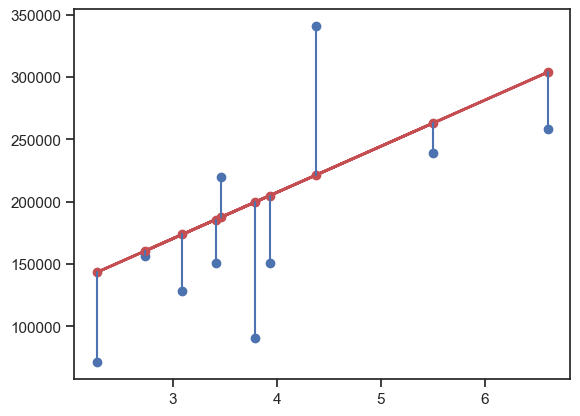

In [11]:
# Синими отрезками показаны ошибки между 
# истинными и предсказанными значениями
K_mnk=10

plt.plot(x_array[1:K_mnk+1], y_array[1:K_mnk+1], 'bo')
plt.plot(x_array[1:K_mnk+1], y_array_regr[1:K_mnk+1], '-ro', linewidth=2.0)

for i in range(len(x_array[1:K_mnk+1])):
    x1 = x_array[1:K_mnk+1][i]
    y1 = y_array[1:K_mnk+1][i]
    y2 = y_array_regr[1:K_mnk+1][i]
    plt.plot([x1,x1],[y1,y2],'b-')

plt.show()

Использование метода наименьших квадратов предполагает решение задачи оптимизации одним из методов оптимизации. Одним из наиболее часто используемых методов является: 

## [Градиентный спуск](https://ru.wikipedia.org/wiki/%D0%93%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA) или метод наискорейшего спуска

Обычно в градиентном спуске рассматривается следующая функция потерь:

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \hat{y}_i)^2$$

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - (b_1 \cdot x_i + b_0))^2$$

Найдем частные производные функции потерь по коэффициентам регресии:

$$ \frac{\partial L}{\partial b_1} = 
\frac{1}{k} \cdot \sum\limits_{i=1}^k 2 \cdot (y_i - (b_1 \cdot x_i + b_0)) \cdot (-x_i) =
\frac{-2}{k} \cdot \sum\limits_{i=1}^k x_i \cdot (y_i - \hat{y_i})  $$

$$ \frac{\partial L}{\partial b_0} = 
\frac{1}{k} \cdot \sum\limits_{i=1}^k 2 \cdot (y_i - (b_1 \cdot x_i + b_0)) \cdot (-1) =
\frac{-2}{k} \cdot \sum\limits_{i=1}^k (y_i - \hat{y_i})  $$


Будем двигаться с шагом $\lambda$ (learning rate) в направлении антиградиента, выполняя в цикле следующие действия:

$$ b_0 = b_0 - \lambda \cdot \frac{\partial L}{\partial b_0} $$

$$ b_1 = b_1 - \lambda \cdot \frac{\partial L}{\partial b_1} $$

Могут рассматриваться различные критерии остановки цикла. Наиболее простым критерием является сходимость значений коэффициентов - модуль разности между значениями коэффициентов на $i$ и $i-1$ шагах не превышает определенного порога $\epsilon^b$: $|b^i - b^{i-1}| < \epsilon^b$.

В простейшей реализации гиперпараметром алгоритма может являться фиксированное количество эпох.

In [12]:
# Простейшая реализация градиентного спуска
def gradient_descent(x_array : np.ndarray,
                     y_array : np.ndarray,
                     b0_0 : float,
                     b1_0 : float,
                     epochs : int,
                     learning_rate : float = 0.001
                    ) -> Tuple[float, float]:
    # Значения для коэффициентов по умолчанию
    b0, b1 = b0_0, b1_0
    k = float(len(x_array))
    for i in range(epochs): 
        # Вычисление новых предсказанных значений
        # используется векторизованное умножение и сложение для вектора и константы
        y_pred = b1 * x_array + b0
        # Расчет градиентов
        # np.multiply - поэлементное умножение векторов
        dL_db1 = (-2/k) * np.sum(np.multiply(x_array, (y_array - y_pred)))
        dL_db0 = (-2/k) * np.sum(y_array - y_pred)
        # Изменение значений коэффициентов:
        b1 = b1 - learning_rate * dL_db1
        b0 = b0 - learning_rate * dL_db0
    # Результирующие значения
    y_pred = b1 * x_array + b0
    return b0, b1, y_pred
    

In [13]:
def show_gradient_descent(epochs, b0_0, b1_0):
    grad_b0, grad_b1, grad_y_pred = gradient_descent(x_array, y_array, b0_0, b1_0, epochs)
    print('b0 = {} - (теоретический), {} - (градиентный спуск)'.format(b0, grad_b0))
    print('b1 = {} - (теоретический), {} - (градиентный спуск)'.format(b1, grad_b1))
    print('MSE = {}'.format(mean_squared_error(y_array_regr, grad_y_pred)))
    plt.plot(x_array, y_array, 'g.')
    plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
    plt.plot(x_array, grad_y_pred, 'r', linewidth=2.0)
    plt.show()

b0 = 59283.88316602097 - (теоретический), 3425.484721949733 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 16076.163101361413 - (градиентный спуск)
MSE = 20908121702.40742


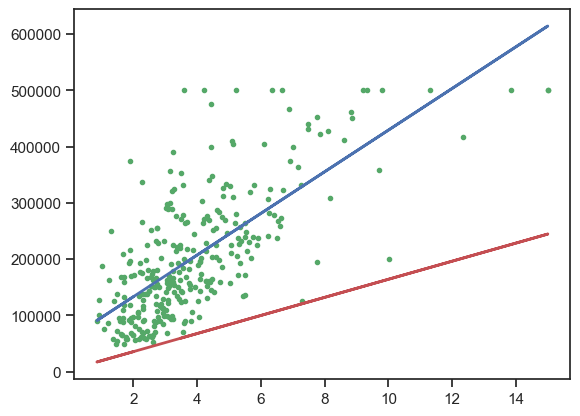

In [14]:
# Примеры использования градиентного спуска
show_gradient_descent(10, 0, 0)

b0 = 59283.88316602097 - (теоретический), 27638.890410969732 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 43283.639019936265 - (градиентный спуск)
MSE = 237765399.52414262


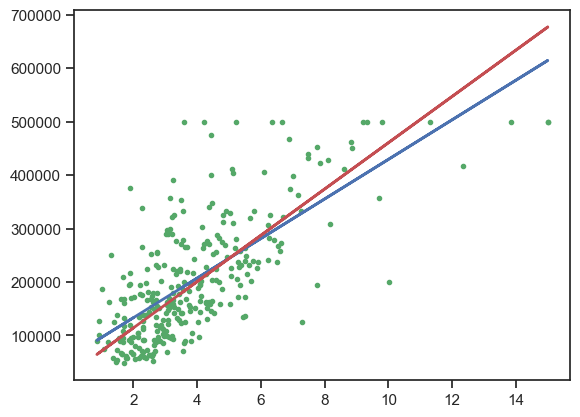

In [15]:
show_gradient_descent(1000, 0, 0)

b0 = 59283.88316602097 - (теоретический), 59283.88316006017 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 37006.972344014095 - (градиентный спуск)
MSE = 8.436224865042422e-12


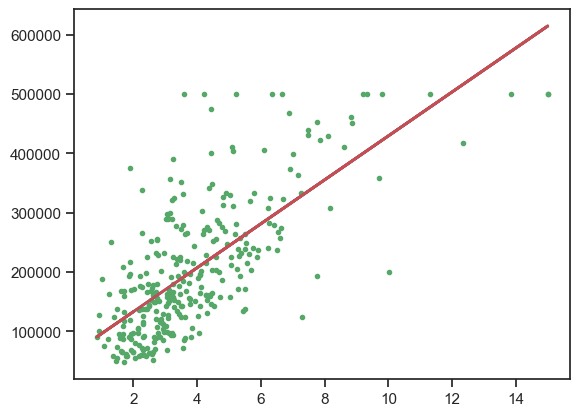

CPU times: total: 672 ms
Wall time: 703 ms


In [16]:
%%time
show_gradient_descent(50000, 0, 0)

b0 = 59283.88316602097 - (теоретический), 59283.88316601188 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 37006.972342833644 - (градиентный спуск)
MSE = 1.979041083629378e-17


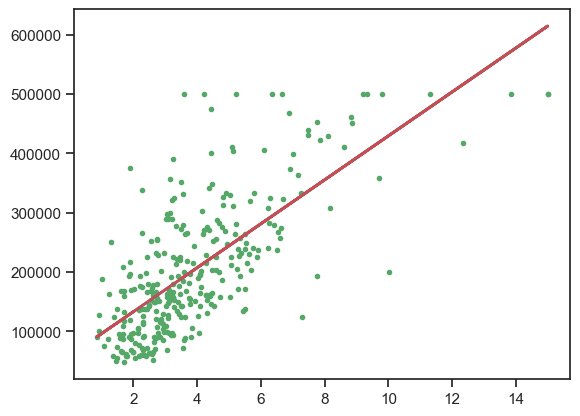

CPU times: total: 1.3 s
Wall time: 1.34 s


In [17]:
%%time
show_gradient_descent(100000, 0, 0)

b0 = 59283.88316602097 - (теоретический), 59283.88316601188 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 37006.972342833644 - (градиентный спуск)
MSE = 1.979041083629378e-17


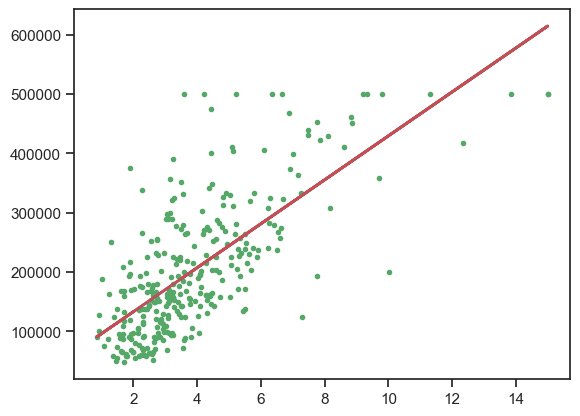

CPU times: total: 12.5 s
Wall time: 12.6 s


In [18]:
%%time
show_gradient_descent(1000000, 0, 0)

b0 = 59283.88316602097 - (теоретический), 27620.009712310493 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 43287.38393632896 - (градиентный спуск)
MSE = 238049205.3134598


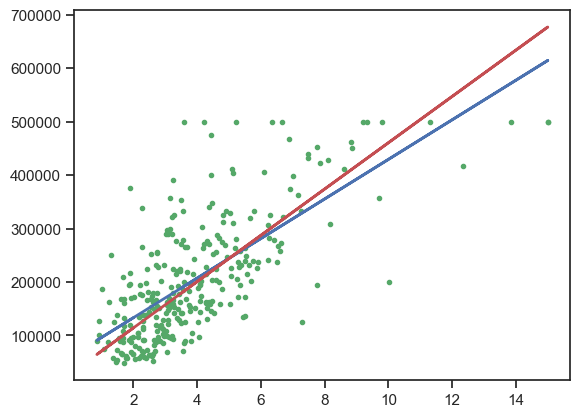

In [19]:
# Сходимость алгоритма может сильно зависеть от начальных значений
show_gradient_descent(1000, -30, 5)

b0 = 59283.88316602097 - (теоретический), 59283.88316601188 - (градиентный спуск)
b1 = 37006.97234283177 - (теоретический), 37006.972342833644 - (градиентный спуск)
MSE = 1.979041083629378e-17


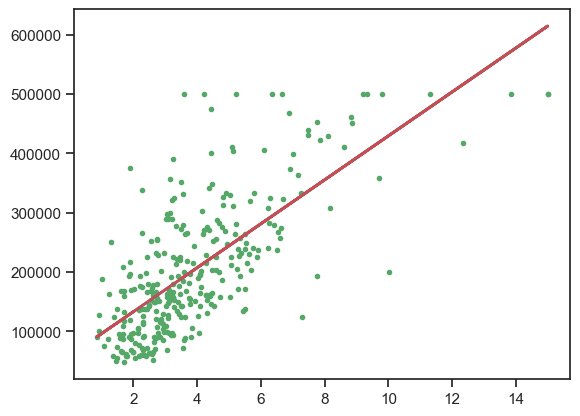

In [20]:
show_gradient_descent(100000, -30, 5)

### Использование класса [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) библиотеки scikit-learn.

In [21]:
# Обучим линейную регрессию и сравним коэффициенты с рассчитанными ранее
reg1 = LinearRegression().fit(x_array.reshape(-1, 1), y_array.reshape(-1, 1))
(b1, reg1.coef_), (b0, reg1.intercept_)

((np.float64(37006.97234283177), array([[37006.97234283]])),
 (np.float64(59283.88316602097), array([59283.88316602])))

### [Стохастический градиентный спуск](http://www.machinelearning.ru/wiki/index.php?title=%D0%A1%D1%82%D0%BE%D1%85%D0%B0%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA)

Пердполагает, что обучение на каждом шаге (эпохе) происходит не на полном наборе данных а на одном случайно выбранном примере. В случае большой обучающей выборки такой подход может многократно ускорить обучение.

В соответствии с [рекомендуемыми методами scikit-learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) стохастический градиентный спуск рекомендуется использовать для задачи регрессии, если размер выборки превышает 100 000 записей.

В библиотеке scikit-learn используются классы:
- [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) для регрессии.
- [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) для классификации.

In [22]:
# Для небольшой выборки качество обучения сильно уступает нестохастическому градиентному спуску.
print('Размер выборки - {}'.format(x_array.shape[0]))
reg2 = SGDRegressor().fit(x_array.reshape(-1, 1), y_array)
(b1, reg2.coef_), (b0, reg2.intercept_)

Размер выборки - 309


((np.float64(37006.97234283177), array([39389.72270708])),
 (np.float64(59283.88316602097), array([52112.36720173])))

## Использование регуляризации в линейных моделях

[Регуляризация](https://ru.wikipedia.org/wiki/%D0%A0%D0%B5%D0%B3%D1%83%D0%BB%D1%8F%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_(%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D0%BA%D0%B0) ) - Это метод, который используется для борьбы с переобучением и улучшения качества моделей.

Известно, что для переобученных моделей характерны большие значения коэффициентов $b_j$. Смысл регуляризации состоит в том, чтобы к функции потерь добавить "штраф" за большие значения коэффициентов. При оптимизации такой функции переобучение становится менее вероятным.

Задача оптимизации (без регуляризации):

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \hat{y}_i)^2 \rightarrow min$$

Коэффициент $b_0$ (константу) можно рассматривать как коэффициент при нулевом признаке, который всегда равен 1 ($x_0=1$). Тогда:

$$ \hat{y} = f(x,b) = b_0 \cdot x_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n = \sum\limits_{j=0}^N b_j \cdot x_j $$

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \sum\limits_{j=0}^N b_j \cdot x_{ij})^2 \rightarrow min$$

#### 1) $L_2$ регуляризация или гребневая регрессия (Ridge Regression) или [регуляризация Тихонова](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D1%80%D0%B5%D0%B3%D1%83%D0%BB%D1%8F%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8_%D0%A2%D0%B8%D1%85%D0%BE%D0%BD%D0%BE%D0%B2%D0%B0)

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \sum\limits_{j=0}^N b_j \cdot x_{ij})^2 + \alpha \cdot \sum\limits_{j=0}^N (b_j)^2 \rightarrow min$$

где $\alpha$ - константа регуляризации.

В библиотеке scikit-learn используются класс [Ridge.](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

#### 2) $L_1$ регуляризация или [LASSO-регрессия](https://en.wikipedia.org/wiki/Lasso_(statistics))

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \sum\limits_{j=0}^N b_j \cdot x_{ij})^2 + \alpha \cdot \sum\limits_{j=0}^N |b_j| \rightarrow min$$

Основная особенность этого метода состоит в том, что коэффициенты $b_j$ близкие к нулю становятся нулевыми. Происходит автоматическое удаление наименее значимых признаков.

В библиотеке scikit-learn используются класс [Lasso.](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

#### 3) Elastic net

Наиболее общим методом является [Elastic net](https://en.wikipedia.org/wiki/Elastic_net_regularization), который обобщает $L_1$ и $L_2$ регуляризацию.

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \sum\limits_{j=0}^N b_j \cdot x_{ij})^2 + \bigg( \alpha_1 \cdot \sum\limits_{j=0}^N |b_j| + \alpha_2 \cdot \sum\limits_{j=0}^N (b_j)^2 \bigg) \rightarrow min$$

Коэффициенты $\alpha_1$ и $\alpha_2$ принято представлять в виде:

$$ \alpha = \alpha_1 + \alpha_2 $$

$$ L1Ratio = \frac{\alpha_1}{\alpha_1 + \alpha_2} $$

Тогда:

$$ L = \frac{1}{k} \cdot \sum\limits_{i=1}^k (y_i - \sum\limits_{j=0}^N b_j \cdot x_{ij})^2 + \alpha \cdot \bigg( L1Ratio \cdot \sum\limits_{j=0}^N |b_j| + \frac{1-L1Ratio}{2} \cdot \sum\limits_{j=0}^N (b_j)^2 \bigg) \rightarrow min$$

При L1Ratio=1 получается $L_1$ - регуляризация. При L1Ratio=0 получается $L_2$ - регуляризация.


В библиотеке scikit-learn используются класс [ElasticNet.](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)


In [23]:
from sklearn.linear_model import Lasso

In [24]:
reg3 = Lasso().fit(x_array.reshape(-1, 1), y_array)
(b1, reg3.coef_), (b0, reg3.intercept_)

((np.float64(37006.97234283177), array([37006.7599685])),
 (np.float64(59283.88316602097), np.float64(59284.709289929306)))

In [25]:
from sklearn.linear_model import Ridge

In [26]:
reg4 = Ridge().fit(x_array.reshape(-1, 1), y_array)
(b1, reg4.coef_), (b0, reg4.intercept_)

((np.float64(37006.97234283177), array([36981.55508403])),
 (np.float64(59283.88316602097), np.float64(59382.75483858559)))

In [27]:
from sklearn.linear_model import ElasticNet

In [28]:
reg5 = ElasticNet().fit(x_array.reshape(-1, 1), y_array)
(b1, reg5.coef_), (b0, reg5.intercept_)

((np.float64(37006.97234283177), array([33454.43459572])),
 (np.float64(59283.88316602097), np.float64(73103.05035771169)))

## [Нелинейная регрессия](https://ru.wikipedia.org/wiki/%D0%9D%D0%B5%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F)

Используется в том случае, когда данные аппроксимируются моделью, которая является более сложной, чем линейная.

В библиотеке scikit-learn реализован класс [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) для [полиномиальной регрессии.](http://www.machinelearning.ru/wiki/index.php?title=%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F)

Необходимо отметить, что возведение признака в степень или произведение признаков не является линейным преобразованием признаков и не может отрицательно повлиять на качество модели.

Для комбинации классов используются [конвейры (pipeline).](https://scikit-learn.org/stable/modules/compose.html#pipeline)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [30]:
poly_model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                       ('linear', LinearRegression(fit_intercept=False))])

In [31]:
poly_model.fit(x_array.reshape(-1, 1), y_array)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('linear', LinearRegression(fit_intercept=False))])

In [32]:
poly_y_pred = poly_model.predict(x_array.reshape(-1, 1))

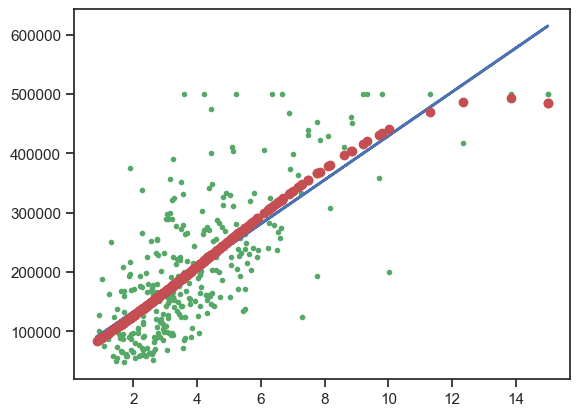

In [33]:
plt.plot(x_array, y_array, 'g.')
plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
plt.plot(x_array, poly_y_pred, 'ro')
plt.show()

In [34]:
# Степени полинома
poly_model.named_steps['linear'].coef_, poly_model.named_steps['linear'].intercept_

(array([54737.82322571, 31908.24597364,  2411.7920554 ,  -175.28708553]), 0.0)

In [35]:
def test_poly_model(degree=3):
    poly_model = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                       ('linear', LinearRegression(fit_intercept=False))])
    poly_model.fit(x_array.reshape(-1, 1), y_array)
    poly_y_pred = poly_model.predict(x_array.reshape(-1, 1))
    
    plt.plot(x_array, y_array, 'g.')
    plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
    plt.plot(x_array, poly_y_pred, 'ro')
    plt.show()
    
    print('Степени полинома - {}'.format(poly_model.named_steps['linear'].coef_))

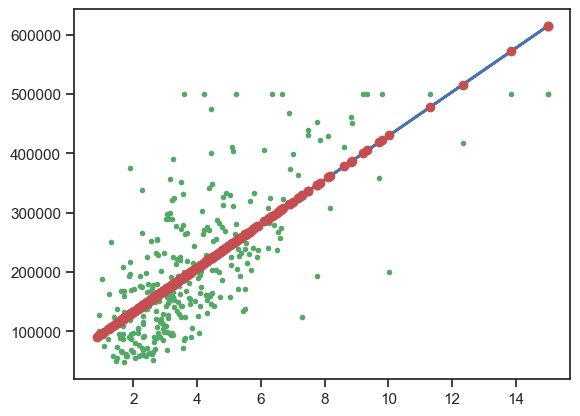

Степени полинома - [59283.88316602 37006.97234283]


In [36]:
test_poly_model(degree=1)

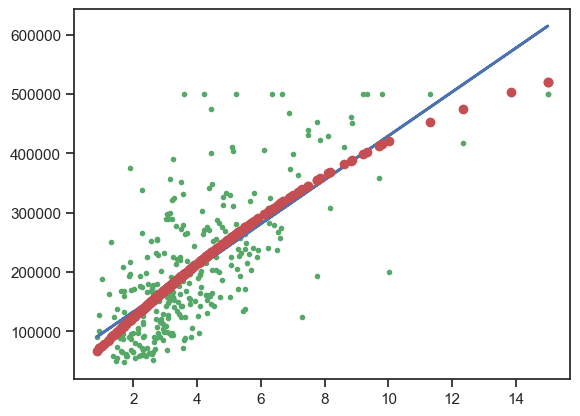

Степени полинома - [23260.47635147 53067.76564741 -1333.25246231]


In [37]:
test_poly_model(degree=2)

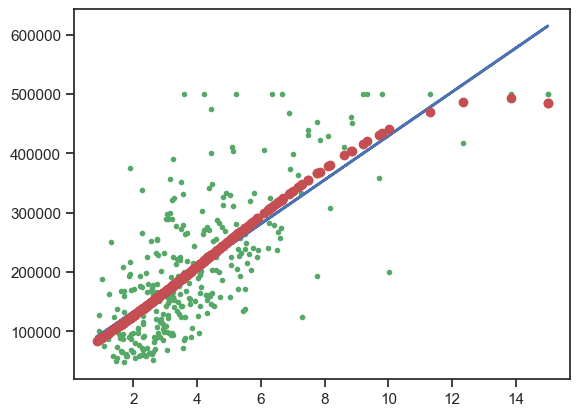

Степени полинома - [54737.82322571 31908.24597364  2411.7920554   -175.28708553]


In [38]:
test_poly_model(degree=3)

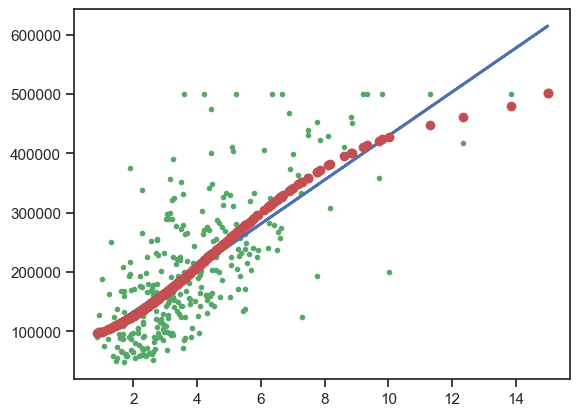

Степени полинома - [ 9.02359890e+04 -1.36891392e+03  1.20315815e+04 -1.20936130e+03
  3.56860016e+01]


In [39]:
test_poly_model(degree=4)

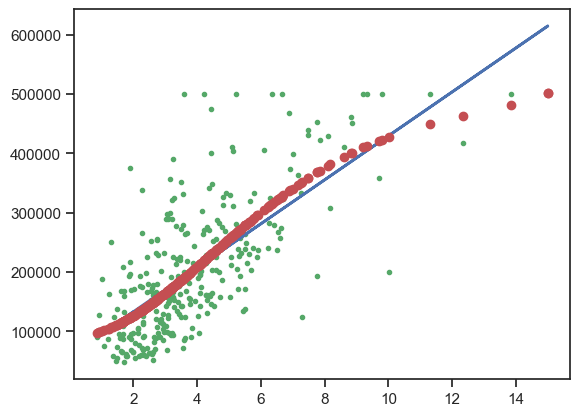

Степени полинома - [ 9.37379629e+04 -5.62986336e+03  1.37724065e+04 -1.51388172e+03
  5.89972680e+01 -6.38064823e-01]


In [40]:
test_poly_model(degree=5)

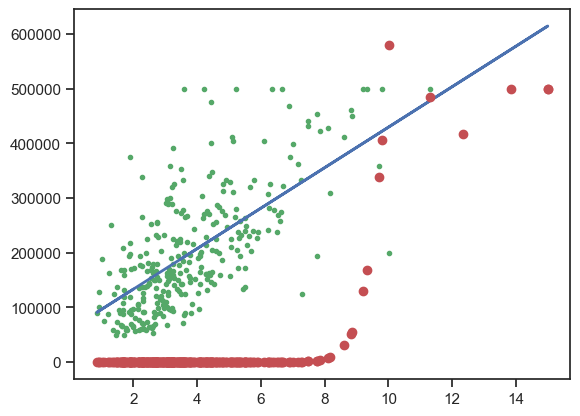

Степени полинома - [ 2.18475713e-27 -1.25431346e-27  3.37889167e-31  6.67178203e-35
  2.92610850e-38  2.93873588e-39  3.62597539e-45  1.23652628e-44
  1.17967019e-43  1.12301743e-42  1.06621706e-41  1.00896238e-40
  9.50994294e-40  8.92107026e-39  8.32156175e-38  7.71068999e-37
  7.08856847e-36  6.45629378e-35  5.81610009e-34  5.17151617e-33
  4.52751002e-32  3.89059925e-31  3.26889620e-30  2.67204614e-29
  2.11100504e-28  1.59759167e-27  1.14374169e-26  7.60394317e-26
  4.55968591e-25  2.34455935e-24  9.33055198e-24  2.15670134e-23
 -7.20815878e-24  8.50727383e-25 -4.38649689e-26  8.40560646e-28]


In [41]:
test_poly_model(degree=35)

## [Логистическая регрессия](https://ru.wikipedia.org/wiki/%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F) 

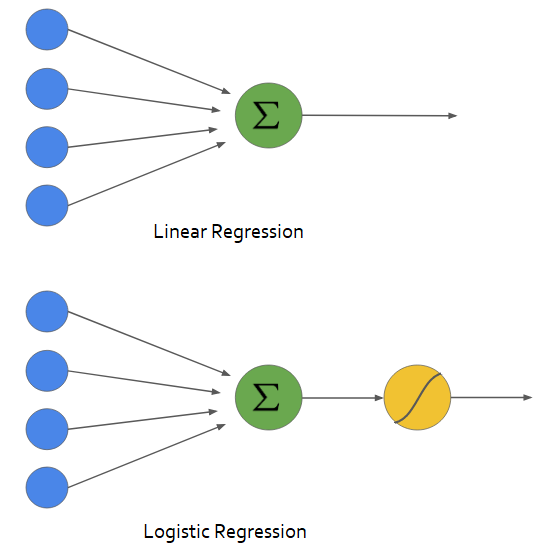

In [42]:
# Источник - https://towardsdatascience.com/building-a-logistic-regression-in-python-301d27367c24
Image('img/lr.png', width='50%')

Не смотря на присутствие слова "регрессия" в названии метода, данный метод используется для решения задачи бинарной классификации.

Метод основан на использовании [логистической кривой или сигмоиды:](https://ru.wikipedia.org/wiki/%D0%A1%D0%B8%D0%B3%D0%BC%D0%BE%D0%B8%D0%B4%D0%B0)

$$f(x)=\frac{1}{1+e^{-x}}$$

In [43]:
# Определение функции
# f(0)=0.5
x = np.linspace(-7, 7, 31)
y = 1 / (1 + np.exp(-x))
list(zip(x,y))

[(np.float64(-7.0), np.float64(0.0009110511944006454)),
 (np.float64(-6.533333333333333), np.float64(0.0014520391100099122)),
 (np.float64(-6.066666666666666), np.float64(0.0023135251651203942)),
 (np.float64(-5.6), np.float64(0.003684239899435989)),
 (np.float64(-5.133333333333333), np.float64(0.005862302196338335)),
 (np.float64(-4.666666666666666), np.float64(0.009315959345066693)),
 (np.float64(-4.2), np.float64(0.014774031693273055)),
 (np.float64(-3.7333333333333334), np.float64(0.023354516476977092)),
 (np.float64(-3.2666666666666666), np.float64(0.03673259067202974)),
 (np.float64(-2.8), np.float64(0.057324175898868755)),
 (np.float64(-2.333333333333333), np.float64(0.08839967720705845)),
 (np.float64(-1.8666666666666663), np.float64(0.1339278883240737)),
 (np.float64(-1.4000000000000004), np.float64(0.1978161114414182)),
 (np.float64(-0.9333333333333336), np.float64(0.28224894304225995)),
 (np.float64(-0.4666666666666668), np.float64(0.3854055017324505)),
 (np.float64(0.0), np

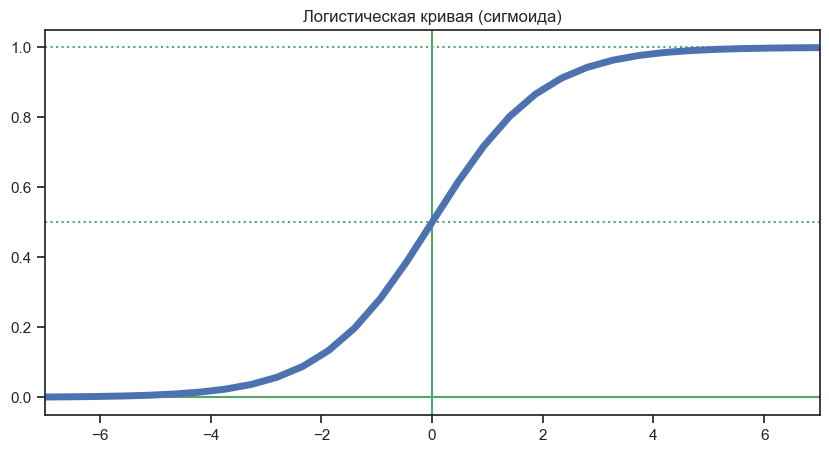

In [44]:
# Вывод графика и осей
plt.figure(figsize=(10, 5))
plt.plot([-7, 7], [0, 0], "g-")
plt.plot([-7, 7], [0.5, 0.5], "g:")
plt.plot([-7, 7], [1, 1], "g:")
plt.plot([0, 0], [-1.1, 1.1], "g-")
plt.plot(x, y, "b-", linewidth=5)
plt.axis([-7, 7, -0.05, 1.05])
plt.title('Логистическая кривая (сигмоида)')
plt.show() 

Модель линейной регрессии 

$$ z(x) = f(x,b) = b_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n$$

(диапазон $z(x) \in (- \infty, \infty)$)

может быть использована как параметр сигмоиды:

$$h(z)=\frac{1}{1+e^{-z}}$$

(диапазон $ h(z) \in (0, 1)$)

Таким образом, $h(z)$ можно рассматривать как вероятность принадлежности объекта $x_i$ к единичному классу. Вероятность принадлежности объекта $x_i$ к нулевому классу $1-h(z)$.

Подставляя параметр $z(x)$ в функцию $h(x)=h(z(x))$ получаем:

$$h(x)=\frac{1}{1+e^{-(b_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n)}}$$

Используем следующую функцию потерь:

$$ cost = \left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
-ln(h(x)), y=1 
\\
-ln(1-h(x)), y=0
\end{array}
\right.
$$

Такой вид функции используется для того, чтобы создать максимально сильный штраф при несопадении истинного и предсказанного классов.

Комбинируя оба условия получаем:

$$cost(h(x),y)= -y \cdot ln(h(x)) - (1-y) \cdot ln(1-h(x))$$

Формируем полную функцию потерь (параметры $b$ неявно входят в $h(x_i)$):

$$ L(b) = - \frac{1}{k} \cdot \sum\limits_{i=1}^k 
\Big(
y_i \cdot ln(h(x_i)) + (1-y_i) \cdot ln(1-h(x_i))
\Big) = $$

$$ L(b) = - \frac{1}{k} \cdot \sum\limits_{i=1}^k 
\Big(
y_i \cdot ln \Big( \frac{1}{1+e^{-(b_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n)}}\Big) + (1-y_i) \cdot ln \Big( 1-\frac{1}{1+e^{-(b_0 + b_1 \cdot x_1 + \dots + b_n \cdot x_n )}}\Big)
\Big) $$

Частные производные полной функции потерь по коэффициентам регресии $b^j$:

$$ \frac{\partial L}{\partial b^j} = 
\frac{1}{k} \cdot \sum\limits_{i=1}^k 
(h(x_i) - y_i) \cdot x_i^j
$$

Детальное описание вывода производной приведено [в статье](https://medium.com/analytics-vidhya/derivative-of-log-loss-function-for-logistic-regression-9b832f025c2d).

Если набор данных состоит из двух признаков, то он может быть визуализирован на плоскости.

В этом случае граничное условие:

$$b_0 + b_1 \cdot x_1 + b_2 \cdot x_2 = 0$$

Тогда:

$$x_2 = - \frac{b_0 + b_1 \cdot x_1}{b_2}$$


Реализуем градиентный спуск для логистической регресии.

In [45]:
# Подготовка данных
housing_grad = Housing_regr
housing_grad_x_ds_lr = housing_grad[['longitude', 'latitude']]
housing_grad_x_ds_lr['x0'] = 1

C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\1559728469.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_grad_x_ds_lr['x0'] = 1


In [46]:
def regr_to_cl(y: float) -> str:
    if y<=150000.0:
        result = 0
    elif y<=350000.0:
        result = 1
    else:
        result = 2        
    return result 

In [47]:
housing_grad_x_ds_lr['target'] = housing_grad[['median_house_value']]
housing_grad_x_ds_lr['target'] = \
housing_grad_x_ds_lr.apply(lambda row: regr_to_cl(row['target']),axis=1)
housing_grad_x_ds_lr.head()

C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\3892840500.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_grad_x_ds_lr['target'] = housing_grad[['median_house_value']]
C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\3892840500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_grad_x_ds_lr['target'] = \


,longitude,latitude,x0,target
0,-122.50,37.75,1,1
1,-118.50,34.46,1,1
2,-122.39,37.60,1,1
3,-117.96,34.03,1,1
4,-121.13,38.87,1,0


In [48]:
np.unique(housing_grad_x_ds_lr['target'])

array([0, 1, 2])

In [49]:
def convert_target_to_binary(array:np.ndarray, target:int) -> np.ndarray:
    # Если целевой признак совпадает с указанным, то 1 иначе 0
    res = [1 if x==target else 0 for x in array]
    return res

In [50]:
bin_housing_grad_y = convert_target_to_binary(housing_grad_x_ds_lr['target'], 0)

In [51]:
housing_grad_x_ds_lr['target_bin'] = bin_housing_grad_y
housing_grad_x_ds_lr.head()

C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\2354436113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_grad_x_ds_lr['target_bin'] = bin_housing_grad_y


,longitude,latitude,x0,target,target_bin
0,-122.50,37.75,1,1,0
1,-118.50,34.46,1,1,0
2,-122.39,37.60,1,1,0
3,-117.96,34.03,1,1,0
4,-121.13,38.87,1,0,1


C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\4189942573.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_viz[idx, 0], X_viz[idx, 1],


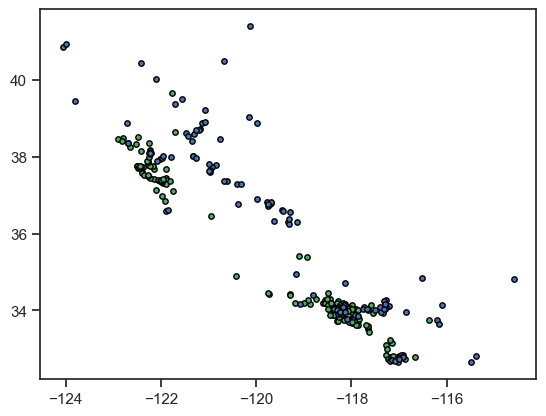

In [52]:
# Визуализация данных
colors = "gb"
#X_viz = housing_grad.data[:, [1,2]]
X_viz = housing_grad_x_ds_lr[['longitude', 'latitude']].values
y_viz = housing_grad_x_ds_lr['target_bin'].values
n_classes = len(np.unique(y_viz))
for i, color in zip(range(n_classes), colors):
    idx = np.where(y_viz == i)
    plt.scatter(X_viz[idx, 0], X_viz[idx, 1], 
                c=color, 
                cmap=plt.cm.RdYlBu, 
                edgecolor='black', s=15)
plt.show()    

In [53]:
# Реализация градиентного спуска
def sigmoid(x):
    '''
    Функция - сигмоида
    '''
    return 1 / (1 + np.exp(-x))

def proba(b, x):
    '''
    Вероятность единичного класса
    '''
    return sigmoid(np.dot(x,b))

def cost_function(b, x, y):
    '''
    Функция потерь
    '''
    k = x.shape[0]
    res = -(1 / k) * np.sum(
        y * np.log(proba(b, x)) 
        + (1 - y) * np.log(1 - proba(b, x)))
    return res

def gradient(b, x, y):
    '''
    Определение градиента
    '''
    k = x.shape[0]
    res = (1 / k) * np.dot(
        x.T, (proba(b, x) - y))

def optimize_lr(x, y, b):
    '''
    Для оптимизации используется функция 
    scipy.optimize.fmin_tnc
    '''
    opt_weights = fmin_tnc(
        func=cost_function, 
        x0=b,          
        fprime=gradient,
        approx_grad=True,
        args=(x, y))
    return opt_weights[0]    

In [54]:
opt_x = housing_grad_x_ds_lr[['x0', 'longitude', 'latitude']].values
opt_x[:5]

array([[   1.  , -122.5 ,   37.75],
       [   1.  , -118.5 ,   34.46],
       [   1.  , -122.39,   37.6 ],
       [   1.  , -117.96,   34.03],
       [   1.  , -121.13,   38.87]])

In [55]:
opt_y = housing_grad_x_ds_lr['target_bin']
opt_y[:5]

0    0
1    0
2    0
3    0
4    1
Name: target_bin, dtype: int64

In [56]:
b_init = np.zeros(3)
b_init

array([0., 0., 0.])

In [57]:
b_res = optimize_lr(opt_x, opt_y, b_init)
b_res

array([19.90490731,  0.33049949,  0.53576263])

In [58]:
def vis_lr(b):
    '''
    Визуализация результата
    '''    
    colors = "gb"
    X_viz = housing_grad_x_ds_lr[['longitude', 'latitude']].values
    y_viz = housing_grad_x_ds_lr['target_bin'].values
    n_classes = len(np.unique(y_viz))
    for i, color in zip(range(n_classes), colors):
        idx = np.where(y_viz == i)
        plt.scatter(X_viz[idx, 0], X_viz[idx, 1], 
                    c=color, 
                    cmap=plt.cm.RdYlBu, 
                    edgecolor='black', s=15)

    t1 = housing_grad_x_ds_lr['longitude'].values    
    t2 = -((b[0]+np.dot(b[1], t1))/b[2])
    plt.plot(t1, t2, 'r', linewidth=2.0)   
    plt.show()    

C:\Users\Bizar\AppData\Local\Temp\ipykernel_15700\2851744340.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_viz[idx, 0], X_viz[idx, 1],


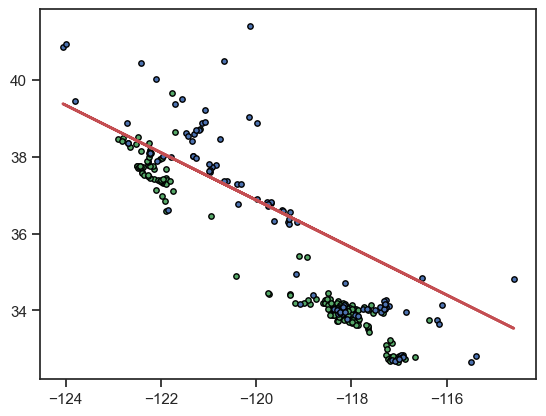

In [59]:
vis_lr(b_res)

### Реализация в sklearn

В sklearn для логистической регрессии используется класс [LogisticRegression.](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
housing_grad_X_train, housing_grad_X_test, housing_grad_y_train, housing_grad_y_test = train_test_split(
    housing_grad_x_ds_lr[['longitude', 'latitude']].values, 
    housing_grad_x_ds_lr['target_bin'].values, test_size=0.5, random_state=1)

In [62]:
cl1 = LogisticRegression()

In [63]:
cl1.fit(housing_grad_X_train, housing_grad_y_train)

LogisticRegression()

In [64]:
pred_housing_grad_y_test = cl1.predict(housing_grad_X_test)
pred_housing_grad_y_test

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0])

In [65]:
pred_housing_grad_y_test_proba = cl1.predict_proba(housing_grad_X_test)
pred_housing_grad_y_test_proba[:10]

array([[0.71816432, 0.28183568],
       [0.76055199, 0.23944801],
       [0.82602325, 0.17397675],
       [0.72563758, 0.27436242],
       [0.77207652, 0.22792348],
       [0.20871171, 0.79128829],
       [0.28112684, 0.71887316],
       [0.81061273, 0.18938727],
       [0.43954432, 0.56045568],
       [0.79443217, 0.20556783]])

In [66]:
# Вероятность принадлежности к 0 классу
[round(x, 4) for x in pred_housing_grad_y_test_proba[:10,0]]

[np.float64(0.7182),
 np.float64(0.7606),
 np.float64(0.826),
 np.float64(0.7256),
 np.float64(0.7721),
 np.float64(0.2087),
 np.float64(0.2811),
 np.float64(0.8106),
 np.float64(0.4395),
 np.float64(0.7944)]

In [67]:
# Вероятность принадлежности к 1 классу
[round(x, 4) for x in pred_housing_grad_y_test_proba[:10,1]]

[np.float64(0.2818),
 np.float64(0.2394),
 np.float64(0.174),
 np.float64(0.2744),
 np.float64(0.2279),
 np.float64(0.7913),
 np.float64(0.7189),
 np.float64(0.1894),
 np.float64(0.5605),
 np.float64(0.2056)]

In [68]:
# Сумма вероятностей равна 1
pred_housing_grad_y_test_proba[:10,0] + pred_housing_grad_y_test_proba[:10,1]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [69]:
accuracy_score(housing_grad_y_test, pred_housing_grad_y_test)

0.8064516129032258

In [70]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [71]:
print_accuracy_score_for_classes(housing_grad_y_test, pred_housing_grad_y_test)

Метка 	 Accuracy
0 	 0.9690721649484536
1 	 0.5344827586206896


### Случай многоклассовой классификации

Класс LogisticRegression может быть использован для многоклассовой классификации. В этом случае для каждого класса создается отдельная модель логистической регресии, каждая модель обучается по схеме "один-против-остальных".

# Дополнительные источники
- https://habr.com/ru/company/io/blog/265007/
- https://habr.com/ru/post/307004/
- https://habr.com/ru/company/ods/blog/323890/
- https://towardsdatascience.com/building-a-logistic-regression-in-python-301d27367c24
- https://medium.com/analytics-vidhya/derivative-of-log-loss-function-for-logistic-regression-9b832f025c2d
